# **Finding Lane Lines on the Road** 
***
In this project, you will use the tools you learned about in the lesson to identify lane lines on the road.  You can develop your pipeline on a series of individual images, and later apply the result to a video stream (really just a series of images). Check out the video clip "raw-lines-example.mp4" (also contained in this repository) to see what the output should look like after using the helper functions below. 

Once you have a result that looks roughly like "raw-lines-example.mp4", you'll need to get creative and try to average and/or extrapolate the line segments you've detected to map out the full extent of the lane lines.  You can see an example of the result you're going for in the video "P1_example.mp4".  Ultimately, you would like to draw just one line for the left side of the lane, and one for the right.

---
Let's have a look at our first image called 'test_images/solidWhiteRight.jpg'.  Run the 2 cells below (hit Shift-Enter or the "play" button above) to display the image.

**Note: If, at any point, you encounter frozen display windows or other confounding issues, you can always start again with a clean slate by going to the "Kernel" menu above and selecting "Restart & Clear Output".**

---

**The tools you have are color selection, region of interest selection, grayscaling, Gaussian smoothing, Canny Edge Detection and Hough Tranform line detection.  You  are also free to explore and try other techniques that were not presented in the lesson.  Your goal is piece together a pipeline to detect the line segments in the image, then average/extrapolate them and draw them onto the image for display (as below).  Once you have a working pipeline, try it out on the video stream below.**

---

<figure>
 <img src="line-segments-example.jpg" width="380" alt="Combined Image" />
 <figcaption>
 <p></p> 
 <p style="text-align: center;"> Your output should look something like this (above) after detecting line segments using the helper functions below </p> 
 </figcaption>
</figure>
 <p></p> 
<figure>
 <img src="laneLines_thirdPass.jpg" width="380" alt="Combined Image" />
 <figcaption>
 <p></p> 
 <p style="text-align: center;"> Your goal is to connect/average/extrapolate line segments to get output like this</p> 
 </figcaption>
</figure>

**Run the cell below to import some packages.  If you get an `import error` for a package you've already installed, try changing your kernel (select the Kernel menu above --> Change Kernel).  Still have problems?  Try relaunching Jupyter Notebook from the terminal prompt.  Also, see [this forum post](https://carnd-forums.udacity.com/cq/viewquestion.action?spaceKey=CAR&id=29496372&questionTitle=finding-lanes---import-cv2-fails-even-though-python-in-the-terminal-window-has-no-problem-with-import-cv2) for more troubleshooting tips.**  

In [ ]:
#importing some useful packages
import matplotlib.pyplot as plt
import matplotlib.image as mpimg
import numpy as np
import cv2
%matplotlib inline

In [ ]:
#reading in an image
image = mpimg.imread('test_images/solidWhiteRight.jpg')
#printing out some stats and plotting
print('This image is:', type(image), 'with dimesions:', image.shape)
plt.imshow(image)  # if you wanted to show a single color channel image called 'gray', for example, call as plt.imshow(gray, cmap='gray')

**Some OpenCV functions (beyond those introduced in the lesson) that might be useful for this project are:**

`cv2.inRange()` for color selection  
`cv2.fillPoly()` for regions selection  
`cv2.line()` to draw lines on an image given endpoints  
`cv2.addWeighted()` to coadd / overlay two images
`cv2.cvtColor()` to grayscale or change color
`cv2.imwrite()` to output images to file  
`cv2.bitwise_and()` to apply a mask to an image

**Check out the OpenCV documentation to learn about these and discover even more awesome functionality!**

Below are some helper functions to help get you started. They should look familiar from the lesson!

In [82]:
import math
from collections import deque

def grayscale(img):
    """Applies the Grayscale transform
    This will return an image with only one color channel
    but NOTE: to see the returned image as grayscale
    (assuming your grayscaled image is called 'gray')
    you should call plt.imshow(gray, cmap='gray')"""
    return cv2.cvtColor(img, cv2.COLOR_RGB2GRAY)
    # Or use BGR2GRAY if you read an image with cv2.imread()
    # return cv2.cvtColor(img, cv2.COLOR_BGR2GRAY)
    
def color_select(img, r_threshold=200, g_threshold=200, b_threshold=200):
    # Grab the x and y size and make a copy of the image
    ysize = img.shape[0]
    xsize = img.shape[1]
    color_select = np.copy(img)

    rgb_threshold = [r_threshold, g_threshold, b_threshold]
    thresholds = (img[:,:,0] < rgb_threshold[0]) \
            | (img[:,:,1] < rgb_threshold[1]) \
            | (img[:,:,2] < rgb_threshold[2])
    color_select[thresholds] = [0,0,0]
    return color_select

def canny(img, low_threshold, high_threshold):
    """Applies the Canny transform"""
    return cv2.Canny(img, low_threshold, high_threshold)

def gaussian_blur(img, kernel_size):
    """Applies a Gaussian Noise kernel"""
    return cv2.GaussianBlur(img, (kernel_size, kernel_size), 0)

def region_of_interest(img, vertices):
    """
    Applies an image mask.
    
    Only keeps the region of the image defined by the polygon
    formed from `vertices`. The rest of the image is set to black.
    """
    #defining a blank mask to start with
    mask = np.zeros_like(img)   
    
    #defining a 3 channel or 1 channel color to fill the mask with depending on the input image
    if len(img.shape) > 2:
        channel_count = img.shape[2]  # i.e. 3 or 4 depending on your image
        ignore_mask_color = (255,) * channel_count
    else:
        ignore_mask_color = 255
        
    #filling pixels inside the polygon defined by "vertices" with the fill color    
    cv2.fillPoly(mask, vertices, ignore_mask_color)
    
    #returning the image only where mask pixels are nonzero
    masked_image = cv2.bitwise_and(img, mask)
    return masked_image

ls_cache = deque()
rs_cache = deque()
def smooth_slope(cache, v):
    if(len(cache)>=5):
        cache.popleft()
        
    cache.append(v)
    return np.average(cache)

def draw_lines(img, lines, color=[255, 0, 0], thickness=2):
    """
    NOTE: this is the function you might want to use as a starting point once you want to 
    average/extrapolate the line segments you detect to map out the full
    extent of the lane (going from the result shown in raw-lines-example.mp4
    to that shown in P1_example.mp4).  
    
    Think about things like separating line segments by their 
    slope ((y2-y1)/(x2-x1)) to decide which segments are part of the left
    line vs. the right line.  Then, you can average the position of each of 
    the lines and extrapolate to the top and bottom of the lane.
    
    This function draws `lines` with `color` and `thickness`.    
    Lines are drawn on the image inplace (mutates the image).
    If you want to make the lines semi-transparent, think about combining
    this function with the weighted_img() function below
    """
    w = img.shape[1]
    h = img.shape[0]
    left_lane = []
    left_s = []
    left_x = [w/2]
    right_lane = []
    right_s = []
    right_x = [w/2]
    lbx = rtx = w
    rbx = rby = lby = ltx = 0
    rty = lty = h
    y_bar = 340

    for line in lines:
        for x1,y1,x2,y2 in line:
            if(x1==x2) or (y1==y2):
                continue
                
            s = ((y2-y1)/(x2-x1))
            tx = int((y_bar - y1)/s + x1)
            if (s>0.0):
                right_lane.append(line)
                right_s.append(s)
                if(tx>w/2):
                    right_x.append(tx)
                rbx = max([rbx, x1, x2])
                rby = max([rby, y1, y2])
                rtx = min([rtx, x1, x2])
                rty = min([rty, y1, y2])
            else:
                left_lane.append(line)
                left_s.append(s)
                if(tx<w/2):
                    left_x.append(tx)
                lbx = min([lbx, x1, x2])
                lby = max([lby, y1, y2])
                ltx = max([ltx, x1, x2])
                lty = min([lty, y1, y2])
                
    rs = np.median(right_s)
    ls = np.median(left_s)
    r_tx = int(np.median(right_x))
    l_tx = int(np.median(left_x))
    #print('left_lane: ', len(left_lane), lbx, lby, ltx, lty, ls)
    #print('right_lane: ', len(right_lane), rbx, rby, rtx, rty, rs)

    if rs==0.0 or ls==0.0 or math.isnan(rs) or math.isnan(ls) or math.isnan(r_tx) or math.isnan(l_tx):
        return

    global ls_cache
    global rs_cache
    print('rs & ls: ', rs, ls)
    ls = smooth_slope(ls_cache, ls)
    rs = smooth_slope(rs_cache, rs)    
    print('r_tx & l_tx & rs & ls: ', r_tx, l_tx, rs, ls)
    # intersect the bottom
    cv2.line(img, (l_tx, y_bar), (int((h-y_bar)/ls+l_tx), h), [0, 0, 255], 10)
    cv2.line(img, (r_tx, y_bar), (int((h-y_bar)/rs+r_tx), h), [0, 255, 0], 10)

    #cv2.line(img, (lbx, lby), (ltx, lty), [0, 0, 255], 10)
    #cv2.line(img, (rbx, rby), (rtx, rty), [0, 255, 0], 10)
    
    # intersect the y_bar
    #cv2.line(img, (lbx, lby), (int((y_bar-lby)/ls+lbx), int(y_bar)), [0, 0, 255], 10)
    #cv2.line(img, (rbx, rby), (int((y_bar-rby)/rs+rbx), int(y_bar)), [0, 255, 0], 10)

    #debugging lines
    """
    for line in lines:
        for x1,y1,x2,y2 in line:
            cv2.line(img, (x1, y1), (x2, y2), [255, 0, 0], thickness)
    
    for line in left_lane:
        for x1,y1,x2,y2 in line:
            cv2.line(img, (x1, y1), (x2, y2), [0, 0, 255], thickness)

    for line in right_lane:
        for x1,y1,x2,y2 in line:
            cv2.line(img, (x1, y1), (x2, y2), [0, 255, 0], thickness)
            
    cv2.line(img, (0, int(2*h/3)), (w, int(2*h/3)), [255, 255, 0], thickness)
    """
    
def hough_lines(img, rho, theta, threshold, min_line_len, max_line_gap):
    """
    `img` should be the output of a Canny transform.
        
    Returns an image with hough lines drawn.
    """
    lines = cv2.HoughLinesP(img, rho, theta, threshold, np.array([]), minLineLength=min_line_len, maxLineGap=max_line_gap)
    line_img = np.zeros((img.shape[0], img.shape[1], 3), dtype=np.uint8)
    # cv2.putText(img, "Lane Found", (450, 50), cv2.FONT_HERSHEY_PLAIN, 1.0, (255, 255, 255))
    draw_lines(line_img, lines)
    return line_img

# Python 3 has support for cool math symbols.

def weighted_img(img, initial_img, α=0.8, β=1., λ=0.):
    """
    `img` is the output of the hough_lines(), An image with lines drawn on it.
    Should be a blank image (all black) with lines drawn on it.
    
    `initial_img` should be the image before any processing.
    
    The result image is computed as follows:
    
    initial_img * α + img * β + λ
    NOTE: initial_img and img must be the same shape!
    """
    return cv2.addWeighted(initial_img, α, img, β, λ)

## Test on Images

Now you should build your pipeline to work on the images in the directory "test_images"  
**You should make sure your pipeline works well on these images before you try the videos.**

In [ ]:
import os
os.listdir("test_images/")

run your solution on all test_images and make copies into the test_images directory).

This image is: <class 'numpy.ndarray'> with dimesions: (540, 960, 3)


rs & ls:  0.666666666667 -0.701351351351
r_tx & l_tx & rs & ls:  534 431 0.666666666667 -0.701351351351


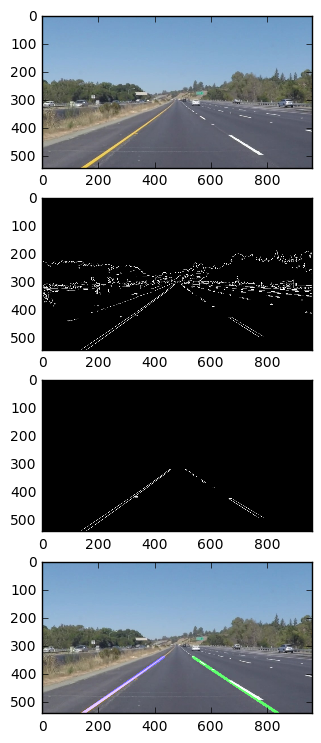

In [83]:
# TODO: Build your pipeline that will draw lane lines on the test_images
# then save them to the test_images directory.
#reading in an image
initial_image = mpimg.imread('test_images/solidYellowLeft.jpg')
print('This image is:', type(initial_image), 'with dimesions:', initial_image.shape)

fig = plt.figure(figsize=(12, 9), dpi=80)
a=fig.add_subplot(4,1,1)
plt.imshow(initial_image)

kernel_size=3

img = grayscale(initial_image)
img = gaussian_blur(img, kernel_size)
low_threshold=50
high_threshold=150
img = canny(img, low_threshold, high_threshold)
b=fig.add_subplot(4,1,2)
plt.imshow(img, cmap='gray')

vertices = np.array([[(100, 540), (920,540), (520, 320), (450, 320)]], dtype=np.int32)
#vertices = np.array([[(0, 540), (920,540), (520, 320), (450, 320)]], dtype=np.int32)
img = region_of_interest(img, vertices)

d=fig.add_subplot(4,1,3)
plt.imshow(img, cmap='gray')

rho = 1
theta = np.pi/180
threshold = 4
min_line_len = 4
max_line_gap = 4
img=hough_lines(img, rho, theta, threshold, min_line_len, max_line_gap)


#plt.imshow(img, cmap='gray')

img = weighted_img(img, initial_image, 1.0)
c = fig.add_subplot(4,1,4)
plt.imshow(img)

## Test on Videos

You know what's cooler than drawing lanes over images? Drawing lanes over video!

We can test our solution on two provided videos:

`solidWhiteRight.mp4`

`solidYellowLeft.mp4`

**Note: if you get an `import error` when you run the next cell, try changing your kernel (select the Kernel menu above --> Change Kernel).  Still have problems?  Try relaunching Jupyter Notebook from the terminal prompt. Also, check out [this forum post](https://carnd-forums.udacity.com/questions/22677062/answers/22677109) for more troubleshooting tips.**

**If you get an error that looks like this:**
```
NeedDownloadError: Need ffmpeg exe. 
You can download it by calling: 
imageio.plugins.ffmpeg.download()
```
**Follow the instructions in the error message and check out [this forum post](https://carnd-forums.udacity.com/display/CAR/questions/26218840/import-videofileclip-error) for more troubleshooting tips across operating systems.**

In [ ]:
# Import everything needed to edit/save/watch video clips
from moviepy.editor import VideoFileClip
# import imageio
from IPython.display import HTML

In [ ]:
def process_image(image):
    # NOTE: The output you return should be a color image (3 channel) for processing video below
    # TODO: put your pipeline here,
    # you should return the final output (image with lines are drawn on lanes)
    kernel_size=3
    img = grayscale(image)
    img = gaussian_blur(img, kernel_size)
    low_threshold=50
    high_threshold=150
    img = canny(img, low_threshold, high_threshold)

    vertices = np.array([[(100, 540), (920,540), (520, 340), (450, 340)]], dtype=np.int32)
    img = region_of_interest(img, vertices)

    rho = 1
    theta = np.pi/180
    threshold = 4
    min_line_len = 4
    max_line_gap = 4
    img=hough_lines(img, rho, theta, threshold, min_line_len, max_line_gap)

    img = weighted_img(img, image, 1.0)
    return img

Let's try the one with the solid white lane on the right first ...

In [84]:
white_output = 'white.mp4'
clip1 = VideoFileClip("solidWhiteRight.mp4")
white_clip = clip1.fl_image(process_image) #NOTE: this function expects color images!!
%time white_clip.write_videofile(white_output, audio=False)

rs & ls:  0.586161187699 -0.818181818182
r_tx & l_tx & rs & ls:  528 409 0.626413927183 -0.759766584767
[MoviePy] >>>> Building video white.mp4
[MoviePy] Writing video white.mp4








  0%|          | 0/222 [00:00<?, ?it/s]





  4%|▎         | 8/222 [00:00<00:02, 77.27it/s]

rs & ls:  0.586161187699 -0.818181818182
r_tx & l_tx & rs & ls:  528 409 0.612996347355 -0.779238329238
rs & ls:  0.637073170732 -0.888888888889
r_tx & l_tx & rs & ls:  537 378 0.619015553199 -0.806650969151
rs & ls:  0.642410951621 -0.75
r_tx & l_tx & rs & ls:  539 424 0.623694632884 -0.795320775321
rs & ls:  0.614143920596 -0.767857142857
r_tx & l_tx & rs & ls:  532 422 0.613190083669 -0.808621933622
rs & ls:  0.6 -0.75
r_tx & l_tx & rs & ls:  532 424 0.61595784613 -0.794985569986
rs & ls:  0.606601731602 -0.625
r_tx & l_tx & rs & ls:  535 442 0.62004595491 -0.756349206349
rs & ls:  0.611111111111 -0.783625730994
r_tx & l_tx & rs & ls:  533 426 0.614853542986 -0.73529657477
rs & ls:  0.595238095238 -0.777777777778
r_tx & l_tx & rs & ls:  529 426 0.605418971709 -0.740852130326
rs & ls:  0.595454545455 -0.677083333333
r_tx & l_tx & rs & ls:  528 426 0.601681096681 -0.722697368421
rs & ls:  0.61620294599 -0.666666666667
r_tx & l_tx & rs & ls:  535 439 0.604921685879 -0.706030701754
rs &

rs & ls:  0.670454545455 -0.667582417582
r_tx & l_tx & rs & ls:  540 449 0.64425848639 -0.711942692947
rs & ls:  0.624 -0.583333333333
r_tx & l_tx & rs & ls:  538 477 0.644737865244 -0.689478924831
rs & ls:  0.714285714286 -0.65
r_tx & l_tx & rs & ls:  541 439 0.660933056192 -0.669478924831








  9%|▊         | 19/222 [00:00<00:02, 83.10it/s]





 14%|█▎        | 30/222 [00:00<00:02, 88.98it/s]

...







 89%|████████▊ | 197/222 [00:02<00:00, 63.20it/s]





 92%|█████████▏| 204/222 [00:03<00:00, 60.43it/s]

rs & ls:  0.585784313725 -0.631578947368
r_tx & l_tx & rs & ls:  538 447 0.583452187888 -0.771810132655
rs & ls:  0.583131639102 -0.777777777778
r_tx & l_tx & rs & ls:  538 436 0.585254658017 -0.768182014741
rs & ls:  0.592592592593 -0.8
r_tx & l_tx & rs & ls:  539 432 0.584022139192 -0.771258937818
rs & ls:  0.59977827051 -0.604166666667
r_tx & l_tx & rs & ls:  539 429 0.587311126627 -0.719226417493
rs & ls:  0.565375302663 -0.755952380952
r_tx & l_tx & rs & ls:  534 437 0.585332423719 -0.713895154553
rs & ls:  0.575718141508 -0.789473684211
r_tx & l_tx & rs & ls:  540 433 0.583319189275 -0.745474101921
rs & ls:  0.552941176471 -0.800284629981
r_tx & l_tx & rs & ls:  538 435 0.577281096749 -0.749975472362
rs & ls:  0.533333333333 -0.75
r_tx & l_tx & rs & ls:  535 440 0.565429244897 -0.739975472362
rs & ls:  0.581168831169 -0.776388888889
r_tx & l_tx & rs & ls:  543 443 0.561707357029 -0.774419916807
rs & ls:  0.550055617353 -0.82
r_tx & l_tx & rs & ls:  529 435 0.558643419967 -0.78722







 95%|█████████▌| 211/222 [00:03<00:00, 57.35it/s]





 98%|█████████▊| 218/222 [00:03<00:00, 60.62it/s]





100%|█████████▉| 221/222 [00:03<00:00, 66.30it/s]

rs & ls:  0.57619047619 -0.769841269841
r_tx & l_tx & rs & ls:  538 436 0.568176649683 -0.79967265779
rs & ls:  0.575892857143 -0.857142857143
r_tx & l_tx & rs & ls:  554 428 0.567121454878 -0.815823451441
rs & ls:  0.546428571429 -0.679487179487
r_tx & l_tx & rs & ls:  533 438 0.566396045693 -0.787720887339
rs & ls:  0.554093567251 -0.777777777778
r_tx & l_tx & rs & ls:  537 432 0.56177285249 -0.781830659762
rs & ls:  0.56862745098 -0.765243902439
r_tx & l_tx & rs & ls:  535 440 0.564246584599 -0.769898597338
rs & ls:  0.400757575758 -0.77358490566
r_tx & l_tx & rs & ls:  535 440 0.529160004512 -0.770647324501
rs & ls:  0.576923076923 -0.80487804878
r_tx & l_tx & rs & ls:  534 433 0.529366048468 -0.760194362829
rs & ls:  0.56862745098 -0.811676510677
r_tx & l_tx & rs & ls:  540 437 0.533805824379 -0.786632229067
rs & ls:  0.571428571429 -0.792857142857
r_tx & l_tx & rs & ls:  532 425 0.537272825214 -0.789648102083
rs & ls:  0.564251582074 -0.75
r_tx & l_tx & rs & ls:  533 436 0.536397

[MoviePy] Done.
[MoviePy] >>>> Video ready: white.mp4 

CPU times: user 2.55 s, sys: 668 ms, total: 3.22 s
Wall time: 3.85 s


Play the video inline, or if you prefer find the video in your filesystem (should be in the same directory) and play it in your video player of choice.

In [ ]:
HTML("""
<video width="960" height="540" controls>
  <source src="{0}">
</video>
""".format(white_output))

**At this point, if you were successful you probably have the Hough line segments drawn onto the road, but what about identifying the full extent of the lane and marking it clearly as in the example video (P1_example.mp4)?  Think about defining a line to run the full length of the visible lane based on the line segments you identified with the Hough Transform.  Modify your draw_lines function accordingly and try re-running your pipeline.**

Now for the one with the solid yellow lane on the left. This one's more tricky!

In [85]:
yellow_output = 'yellow.mp4'
clip2 = VideoFileClip('solidYellowLeft.mp4')
yellow_clip = clip2.fl_image(process_image)
%time yellow_clip.write_videofile(yellow_output, audio=False)

rs & ls:  0.666666666667 -0.594117647059
r_tx & l_tx & rs & ls:  533 438 0.587369948829 -0.765490196078
[MoviePy] >>>> Building video yellow.mp4
[MoviePy] Writing video yellow.mp4








  0%|          | 0/682 [00:00<?, ?it/s]





  1%|          | 4/682 [00:00<00:17, 38.38it/s]

rs & ls:  0.666666666667 -0.594117647059
r_tx & l_tx & rs & ls:  533 438 0.606417567877 -0.725742296919
rs & ls:  0.631578947368 -0.6325
r_tx & l_tx & rs & ls:  532 434 0.619883040936 -0.702242296919
rs & ls:  0.6 -0.617021276596
r_tx & l_tx & rs & ls:  521 442 0.628771929825 -0.654217980809
rs & ls:  0.571428571429 -0.657894736842
r_tx & l_tx & rs & ls:  520 422 0.627268170426 -0.619130261511
rs & ls:  0.625 -0.624245472837
r_tx & l_tx & rs & ls:  535 440 0.618934837093 -0.625155826667
rs & ls:  0.6 -0.621621621622
r_tx & l_tx & rs & ls:  534 441 0.605601503759 -0.630656621579
rs & ls:  0.66091954023 -0.621621621622
r_tx & l_tx & rs & ls:  540 446 0.611469622332 -0.628480945904
rs & ls:  0.4375 -0.64
r_tx & l_tx & rs & ls:  536 444 0.578969622332 -0.633076690584
rs & ls:  0.6 -0.666666666667
r_tx & l_tx & rs & ls:  529 437 0.584683908046 -0.634831076549
rs & ls:  0.5625 -0.662280701754
r_tx & l_tx & rs & ls:  529 437 0.572183908046 -0.642438122333
rs & ls:  0.617647058824 -0.697826086







  2%|▏         | 14/682 [00:00<00:14, 46.89it/s]

rs & ls:  0.607692307692 -0.666666666667
r_tx & l_tx & rs & ls:  525 434 0.615067873303 -0.667466492318
rs & ls:  0.583333333333 -0.622023809524
r_tx & l_tx & rs & ls:  520 442 0.61173453997 -0.658537920889
rs & ls:  0.6 -0.672043010753
r_tx & l_tx & rs & ls:  522 440 0.61923453997 -0.660490382689
rs & ls:  0.636363636364 -0.666666666667
r_tx & l_tx & rs & ls:  540 433 0.622977855478 -0.654258498631
rs & ls:  0.666666666667 -0.651685393258
r_tx & l_tx & rs & ls:  542 438 0.618811188811 -0.655817109374
rs & ls:  0.590277777778 -0.631578947368
r_tx & l_tx & rs & ls:  528 438 0.615328282828 -0.648799565514


...







 97%|█████████▋| 663/682 [00:11<00:00, 54.76it/s]





 98%|█████████▊| 669/682 [00:11<00:00, 56.17it/s]

rs & ls:  0.602325581395 -0.75
r_tx & l_tx & rs & ls:  532 434 0.546909560724 -0.76202020202
rs & ls:  0.6 -0.771929824561
r_tx & l_tx & rs & ls:  521 435 0.566909560724 -0.755295055821
rs & ls:  0.598507462687 -0.754385964912
r_tx & l_tx & rs & ls:  529 431 0.586611053261 -0.760717703349
rs & ls:  0.563492063492 -0.75
r_tx & l_tx & rs & ls:  529 432 0.583976132626 -0.765263157895
rs & ls:  0.589285714286 -0.767598842816
r_tx & l_tx & rs & ls:  524 427 0.590722164372 -0.758782926458
rs & ls:  0.614285714286 -0.711247086247
r_tx & l_tx & rs & ls:  530 439 0.59311419095 -0.751032343707
rs & ls:  0.571428571429 -0.725390156062
r_tx & l_tx & rs & ls:  524 435 0.587399905236 -0.741724410008
rs & ls:  0.631136950904 -0.770108043217
r_tx & l_tx & rs & ls:  530 431 0.593925802879 -0.744868825669
rs & ls:  0.662280701754 -0.743421052632
r_tx & l_tx & rs & ls:  540 434 0.613683530532 -0.743553036195
rs & ls:  0.587585034014 -0.727272727273
r_tx & l_tx & rs & ls:  526 436 0.613343394477 -0.735487







 99%|█████████▉| 675/682 [00:11<00:00, 55.52it/s]





100%|█████████▉| 681/682 [00:11<00:00, 59.33it/s]

rs & ls:  0.53256302521 -0.699453551913
r_tx & l_tx & rs & ls:  520 435 0.601820897123 -0.714163367763
rs & ls:  0.6 -0.75
r_tx & l_tx & rs & ls:  528 435 0.589364756772 -0.715479157237
rs & ls:  0.6 -0.780193236715
r_tx & l_tx & rs & ls:  542 419 0.59184774997 -0.726063259125
rs & ls:  0.5 -0.697986577181
r_tx & l_tx & rs & ls:  526 437 0.559556083303 -0.725337993916
rs & ls:  0.548387096774 -0.705882352941
r_tx & l_tx & rs & ls:  523 439 0.556190024397 -0.72670314375
rs & ls:  0.5 -0.718524920772
r_tx & l_tx & rs & ls:  511 443 0.549677419355 -0.730517417522
rs & ls:  0.59375 -0.755952380952
r_tx & l_tx & rs & ls:  526 434 0.548427419355 -0.731707893712
rs & ls:  0.626600284495 -0.752419354839
r_tx & l_tx & rs & ls:  530 438 0.553747476254 -0.726153117337
rs & ls:  0.555555555556 -0.710591133005
r_tx & l_tx & rs & ls:  524 439 0.564858587365 -0.728674028502


[MoviePy] Done.
[MoviePy] >>>> Video ready: yellow.mp4 

CPU times: user 8.57 s, sys: 2.01 s, total: 10.6 s
Wall time: 12 s


In [ ]:
HTML("""
<video width="960" height="540" controls>
  <source src="{0}">
</video>
""".format(yellow_output))

## Reflections

Congratulations on finding the lane lines!  As the final step in this project, we would like you to share your thoughts on your lane finding pipeline... specifically, how could you imagine making your algorithm better / more robust?  Where will your current algorithm be likely to fail?

Please add your thoughts below,  and if you're up for making your pipeline more robust, be sure to scroll down and check out the optional challenge video below!


## Submission

If you're satisfied with your video outputs it's time to submit!  Submit this ipython notebook for review.


## Optional Challenge

Try your lane finding pipeline on the video below.  Does it still work?  Can you figure out a way to make it more robust?  If you're up for the challenge, modify your pipeline so it works with this video and submit it along with the rest of your project!

In [ ]:
challenge_output = 'extra.mp4'
clip2 = VideoFileClip('challenge.mp4')
challenge_clip = clip2.fl_image(process_image)
%time challenge_clip.write_videofile(challenge_output, audio=False)

In [ ]:
HTML("""
<video width="960" height="540" controls>
  <source src="{0}">
</video>
""".format(challenge_output))